# creforge quickstart

This notebook generates a synthetic credit bureau portfolio and uses it the way a
credit-risk or data team would:

1. Generate and validate the data
2. Vintage curves by risk grade
3. A monthly roll-rate matrix
4. Checking a simple behavioural score against the known risk grade
5. Joint borrowers and guarantors
6. Baseline vs stressed economy

Everything here comes from rules, not real data, so this notebook is safe to share.

```console
pip install creforge matplotlib
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import creforge as cf

cf.__version__

'0.2.0'

## 1. Generate and validate

30,000 borrowers over 36 months takes a few seconds. The same seed always gives
exactly the same data.

In [2]:
cfg = cf.Config.from_profile("baseline", subjects=30_000, months=36, seed=42)
ds = cf.generate(cfg)
{name: ds.table(name).height for name in ("subject", "inquiry", "account", "account_month")}

{'subject': 30000,
 'inquiry': 37267,
 'account': 95755,
 'account_month': 2158217}

In [3]:
report = cf.validate(ds)
print("integrity passed:  ", report.integrity_ok)
print("calibration passed:", report.calibration_ok)
pl.DataFrame([{"product": p, **v} for p, v in report.metrics["products"].items()]).with_columns(
    pl.col("dpd30_share", "annual_writeoff_rate").mul(100).round(2)
).rename({"dpd30_share": "30+ DPD %", "annual_writeoff_rate": "annual write-off %"})

integrity passed:   True
calibration passed: True


product,active_rows,30+ DPD %,annual write-off %
str,i64,f64,f64
"""credit_card""",1103745,3.85,3.68
"""personal_loan""",289787,4.48,3.34
"""mortgage""",314506,0.97,0.41
"""auto_loan""",278086,2.69,1.9
"""overdraft""",89490,3.06,2.8
"""bnpl""",40272,6.8,0.92


The four tables link up through their ids. Here is one borrower's monthly history on
a single account:

In [4]:
ds.account_month.filter(pl.col("account_id") == ds.account["account_id"][0]).head(6)

account_id,as_of_month,balance,amount_due,amount_paid,dpd_bucket,months_in_arrears,status
str,date,f64,f64,f64,enum,i16,enum
"""A1D11ZEG7VM9W""",2023-01-01,494837.03,2679.87,2679.87,"""0""",0,"""current"""
"""A1D11ZEG7VM9W""",2023-02-01,494445.78,2679.87,2679.87,"""0""",0,"""current"""
"""A1D11ZEG7VM9W""",2023-03-01,494052.72,2679.87,2679.87,"""0""",0,"""current"""
"""A1D11ZEG7VM9W""",2023-04-01,493657.84,2679.87,2679.87,"""0""",0,"""current"""
"""A1D11ZEG7VM9W""",2023-05-01,493261.14,2679.87,2679.87,"""0""",0,"""current"""
"""A1D11ZEG7VM9W""",2023-06-01,492862.6,2679.87,2679.87,"""0""",0,"""current"""


## 2. Vintage curves by risk grade

Take accounts opened in the first year of the window and track the share that has
ever reached 90+ DPD (or been written off) by months on book. The latent `risk_grade`
is exported with each borrower, so the curves should fan out from A (best) to E.

In [5]:
acc = ds.account.join(ds.subject.select("subject_id", "risk_grade"), on="subject_id")
cohort = acc.filter(pl.col("inquiry_id").is_not_null() & (pl.col("open_date") < pl.date(2024, 1, 1)))

mob = (pl.col("as_of_month").dt.year() * 12 + pl.col("as_of_month").dt.month()) - (
    pl.col("open_date").dt.year() * 12 + pl.col("open_date").dt.month()
)
hist = ds.account_month.join(cohort.select("account_id", "open_date"), on="account_id").with_columns(
    mob.alias("mob")
)
first_bad = (
    hist.filter(
        pl.col("dpd_bucket").cast(pl.String).is_in(["90-119", "120+"])
        | (pl.col("status") == "written_off")
    )
    .group_by("account_id")
    .agg(pl.col("mob").min().alias("first_bad"))
)
cohort = cohort.join(first_bad, on="account_id", how="left")

horizon = np.arange(0, 25)
grades = ["A", "B", "C", "D", "E"]
curves = {}
for g in grades:
    fb = cohort.filter(pl.col("risk_grade") == g)["first_bad"].to_numpy()
    fb = np.where(np.isnan(fb.astype(float)), np.inf, fb.astype(float))
    curves[g] = [(fb <= k).mean() for k in horizon]

pl.DataFrame({"grade": grades, "accounts": [cohort.filter(pl.col("risk_grade") == g).height for g in grades],
              "bad by month 24 (%)": [round(100 * curves[g][-1], 2) for g in grades]})

grade,accounts,bad by month 24 (%)
str,i64,f64
"""A""",1367,0.07
"""B""",2507,2.19
"""C""",2264,4.9
"""D""",1288,17.24
"""E""",577,37.78


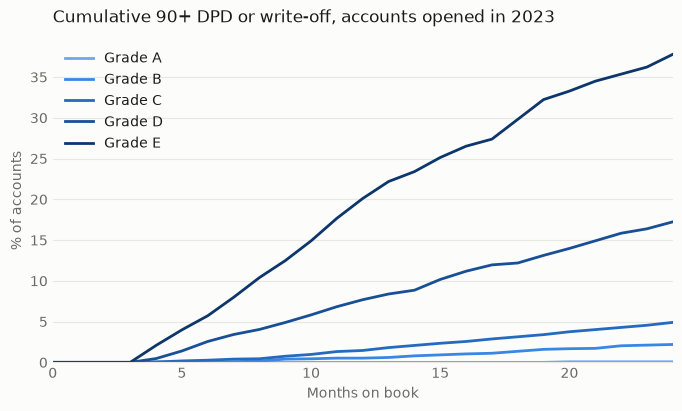

In [6]:
# Ordinal blue ramp: grades are ordered, so one hue from light (A) to dark (E).
RAMP = ["#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
INK, MUTED, GRID = "#1a1a19", "#6b6a64", "#e8e7e1"

def style(ax, title, ylabel):
    ax.set_title(title, loc="left", fontsize=12, color=INK, pad=12)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor("#fcfcfb")
    ax.figure.set_facecolor("#fcfcfb")

fig, ax = plt.subplots(figsize=(8, 4.2))
for g, color in zip(grades, RAMP, strict=True):
    ax.plot(horizon, [100 * v for v in curves[g]], color=color, linewidth=2, label=f"Grade {g}")
style(ax, "Cumulative 90+ DPD or write-off, accounts opened in 2023", "% of accounts")
ax.set_xlabel("Months on book", color=MUTED)
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, labelcolor=INK, loc="upper left")
plt.show()

## 3. Roll-rate matrix

The share of accounts in each DPD bucket this month that are in each bucket next
month. Accounts can move to any better bucket when they pay, but at most **one
bucket worse** per month, so every cell more than one step right of the diagonal is
zero. That's one of the integrity guarantees.

In [7]:
order = ["0", "1-29", "30-59", "60-89", "90-119", "120+"]
moves = (
    ds.account_month.sort("account_id", "as_of_month")
    .with_columns(
        pl.col("dpd_bucket").cast(pl.String).alias("from"),
        pl.when(pl.col("status").shift(-1).over("account_id") == "written_off").then(pl.lit("written off"))
        .when(pl.col("status").shift(-1).over("account_id") == "closed").then(pl.lit("closed"))
        .otherwise(pl.col("dpd_bucket").cast(pl.String).shift(-1).over("account_id")).alias("to"),
    )
    .filter(pl.col("to").is_not_null() & ~pl.col("status").is_in(["written_off", "closed"]))
)
matrix = (
    moves.group_by("from", "to").len()
    .with_columns((100 * pl.col("len") / pl.col("len").sum().over("from")).round(1).alias("pct"))
    .pivot(on="to", index="from", values="pct")
    .fill_null(0.0)
)
cols = [c for c in order + ["closed", "written off"] if c in matrix.columns]
matrix.with_columns(pl.col("from").cast(pl.Enum(order))).sort("from").select("from", *cols)

from,0,1-29,30-59,60-89,90-119,120+,closed,written off
enum,f64,f64,f64,f64,f64,f64,f64,f64
"""0""",96.9,1.4,0.0,0.0,0.0,0.0,1.7,0.0
"""1-29""",49.6,14.8,33.4,0.0,0.0,0.0,2.1,0.0
"""30-59""",16.3,12.1,16.8,53.7,0.0,0.0,1.0,0.0
"""60-89""",8.7,0.0,6.6,16.2,67.8,0.0,0.7,0.0
"""90-119""",5.8,0.0,0.0,4.9,12.9,75.9,0.5,0.0
"""120+""",3.9,0.0,0.0,0.0,2.7,79.8,0.2,13.4


## 4. Checking a behavioural score against the known grade

With real data you never know a borrower's true risk. Here you do. That makes
creforge useful for testing scorecards and features: you can see how close a model
gets to the truth.

Below, a naive behavioural score (worst DPD in the first 12 months) predicts going
90+ in months 12–23. As in a real scorecard build, borrowers already 90+ in the first
12 months are excluded. The score is compared with the latent grade, which is close
to the best any model could do with this data.

In [8]:
def auc(score, target):
    ranks = pl.Series(score).rank("average").to_numpy()
    y = np.asarray(target, dtype=bool)
    n1, n0 = y.sum(), (~y).sum()
    return (ranks[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

m = (pl.col("as_of_month").dt.year() - 2023) * 12 + pl.col("as_of_month").dt.month() - 1
dpd_idx = pl.col("dpd_bucket").cast(pl.String).replace_strict({b: i for i, b in enumerate(order)},
                                                              return_dtype=pl.Int8)
panel = ds.account_month.join(ds.account.select("account_id", "subject_id"), on="account_id").with_columns(
    m.alias("m"), dpd_idx.alias("dpd")
)
early = panel.filter(pl.col("m") < 12).group_by("subject_id").agg(pl.col("dpd").max().alias("worst_dpd_12m"))
later = panel.filter((pl.col("m") >= 12) & (pl.col("m") < 24)).group_by("subject_id").agg(
    ((pl.col("dpd") >= 4) | (pl.col("status") == "written_off")).any().alias("bad_next_12m")
)
data = (
    ds.subject.select("subject_id", pl.col("risk_grade").to_physical().alias("grade_rank"))
    .join(early, on="subject_id").join(later, on="subject_id")
    .filter(pl.col("worst_dpd_12m") < 4)  # exclude borrowers already 90+ (bad at observation)
)
print(f"borrowers scored: {data.height:,}  bad rate: {data['bad_next_12m'].mean():.2%}")
print(f"AUC, worst DPD in first 12 months: {auc(data['worst_dpd_12m'], data['bad_next_12m']):.3f}")
print(f"AUC, latent risk grade (ceiling):  {auc(data['grade_rank'], data['bad_next_12m']):.3f}")

borrowers scored: 23,259  bad rate: 5.63%
AUC, worst DPD in first 12 months: 0.701
AUC, latent risk grade (ceiling):  0.832


## 5. Joint borrowers and guarantors

`account_party` lists everyone on each account: the `primary` borrower, plus a `joint`
co-borrower or a `guarantor` where there is one. Most joint accounts are mortgages; most
guarantees back personal and auto loans.

In [9]:
accounts = ds.account.group_by("product_type").len().rename({"len": "accounts"})
links = (
    ds.account_party.filter(pl.col("role") != "primary")
    .join(ds.account.select("account_id", "product_type"), on="account_id")
    .group_by("product_type", "role").len()
    .pivot(on="role", index="product_type", values="len")
)
(
    accounts.join(links, on="product_type", how="left").fill_null(0)
    .with_columns(
        (100 * pl.col("joint") / pl.col("accounts")).round(1).alias("joint %"),
        (100 * pl.col("guarantor") / pl.col("accounts")).round(1).alias("guaranteed %"),
    )
    .sort("product_type")
)

product_type,accounts,guarantor,joint,joint %,guaranteed %
enum,u32,u32,u32,f64,f64
"""credit_card""",40861,0,0,0.0,0.0
"""personal_loan""",15778,1435,823,5.2,9.1
"""mortgage""",10095,214,4122,40.8,2.1
"""auto_loan""",12602,788,1260,10.0,6.3
"""overdraft""",3346,0,0,0.0,0.0
"""bnpl""",13073,0,0,0.0,0.0


Linked parties change behaviour. A joint account's risk blends both borrowers, and a
guarantor can be called once a loan is 90+ days past due. The validator compares each
group with single-borrower accounts of the same product and primary grade:

In [10]:
parties = report.metrics["parties"]
for key, label in (("joint", "Joint accounts, 12-month bad"), ("guarantor", "Guaranteed loans, write-offs")):
    m = parties[key]
    print(f"{label}: {m['observed']} observed vs {m['expected_if_single']:.0f} expected "
          f"if single-borrower ({m['observed'] / m['expected_if_single']:.2f}x)")
g = parties["guarantor_grade_index"]
print(f"Mean grade index (A=0 ... E=4): guarantors {g['guarantors']}, primaries they back {g['primaries']}")

Joint accounts, 12-month bad: 39 observed vs 68 expected if single-borrower (0.58x)
Guaranteed loans, write-offs: 68 observed vs 162 expected if single-borrower (0.42x)
Mean grade index (A=0 ... E=4): guarantors 0.94, primaries they back 1.92


## 6. Baseline vs stressed economy

The `stressed` profile uses the same borrowers and products, but roll rates ramp up
from month 9 and peak at 1.8× around month 15. With the same seed, the two datasets
share a population, so the difference comes from the economy alone.

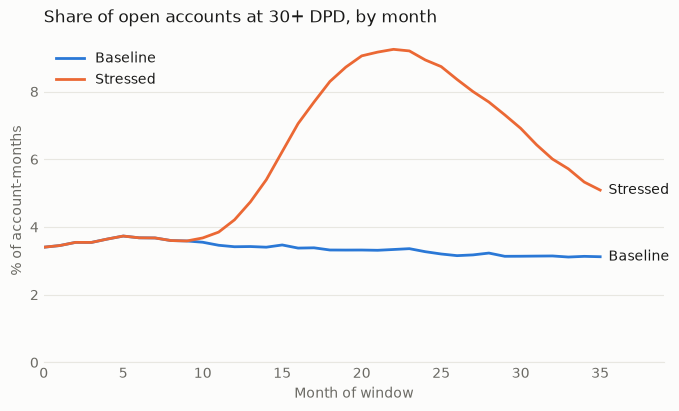

product,baseline write-off %,stressed write-off %
str,f64,f64
"""credit_card""",3.68,6.69
"""personal_loan""",3.34,5.55
"""mortgage""",0.41,1.01
"""auto_loan""",1.9,3.53
"""overdraft""",2.8,4.91
"""bnpl""",0.92,1.29


In [11]:
stressed = cf.validate(cf.generate(cf.Config.from_profile("stressed", subjects=30_000, months=36, seed=42)))
series = {"Baseline": report, "Stressed": stressed}
COLORS = {"Baseline": "#2a78d6", "Stressed": "#eb6834"}

fig, ax = plt.subplots(figsize=(8, 4.2))
for name, rep in series.items():
    by_month = rep.metrics["dpd30_share_by_month"]
    xs = sorted(by_month)
    ys = [100 * by_month[x] for x in xs]
    ax.plot(xs, ys, color=COLORS[name], linewidth=2, label=name)
    ax.annotate(name, (xs[-1], ys[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK, fontsize=10)
style(ax, "Share of open accounts at 30+ DPD, by month", "% of account-months")
ax.set_xlabel("Month of window", color=MUTED)
ax.set_xlim(0, 39)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, labelcolor=INK, loc="upper left")
plt.show()

def writeoff_pct(rep):
    return [round(100 * v["annual_writeoff_rate"], 2) for v in rep.metrics["products"].values()]

pl.DataFrame({
    "product": list(report.metrics["products"]),
    "baseline write-off %": writeoff_pct(report),
    "stressed write-off %": writeoff_pct(stressed),
})

## Next steps

- Write large datasets to disk with `creforge generate --subjects 1000000 --workers 4 -o out`.
- Make your own profile: a YAML file starting with `extends: baseline`.
- See the [README](../README.md) for the full model and the validation rules.